Ready.
   1/34  Karachi            GHI=2050  PVcf=23.3%  v100=5.90  Wcf=37.2%
   2/34  Hyderabad          GHI=2042  PVcf=23.1%  v100=6.65  Wcf=44.3%
   3/34  Jhimpir            GHI=2042  PVcf=23.1%  v100=6.93  Wcf=46.9%
   4/34  Gharo              GHI=2050  PVcf=23.2%  v100=6.71  Wcf=44.9%
   5/34  Thatta             GHI=2050  PVcf=23.2%  v100=6.93  Wcf=46.9%
   6/34  Nawabshah          GHI=2050  PVcf=23.1%  v100=5.82  Wcf=36.4%
   7/34  Sukkur             GHI=2024  PVcf=22.7%  v100=5.00  Wcf=27.9%
   8/34  Badin              GHI=2028  PVcf=22.9%  v100=6.68  Wcf=44.6%
   9/34  Lahore             GHI=1801  PVcf=20.5%  v100=3.84  Wcf=15.7%
  10/34  Multan             GHI=1853  PVcf=20.9%  v100=4.57  Wcf=23.3%
  11/34  Bahawalpur         GHI=1914  PVcf=21.6%  v100=4.67  Wcf=24.4%
  12/34  Dera Ghazi Khan    GHI=1857  PVcf=21.0%  v100=4.97  Wcf=27.6%
  13/34  Rahim Yar Khan     GHI=2040  PVcf=23.0%  v100=4.92  Wcf=27.1%
  14/34  Faisalabad         GHI=1757  PVcf=20.0%  v100=3.82  Wcf=15.5%

Saved solar map.


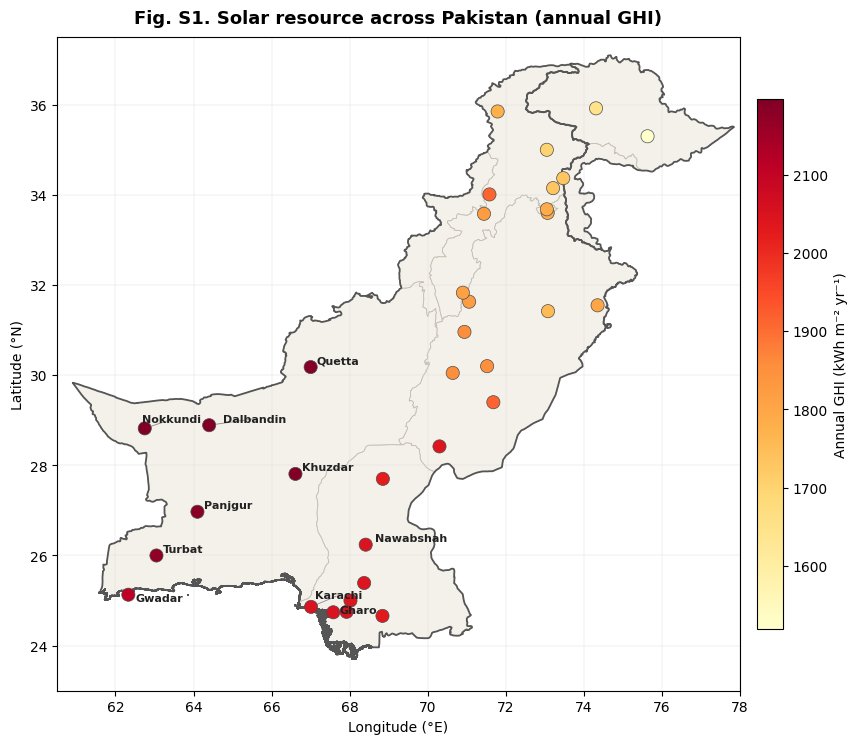

Saved wind map.


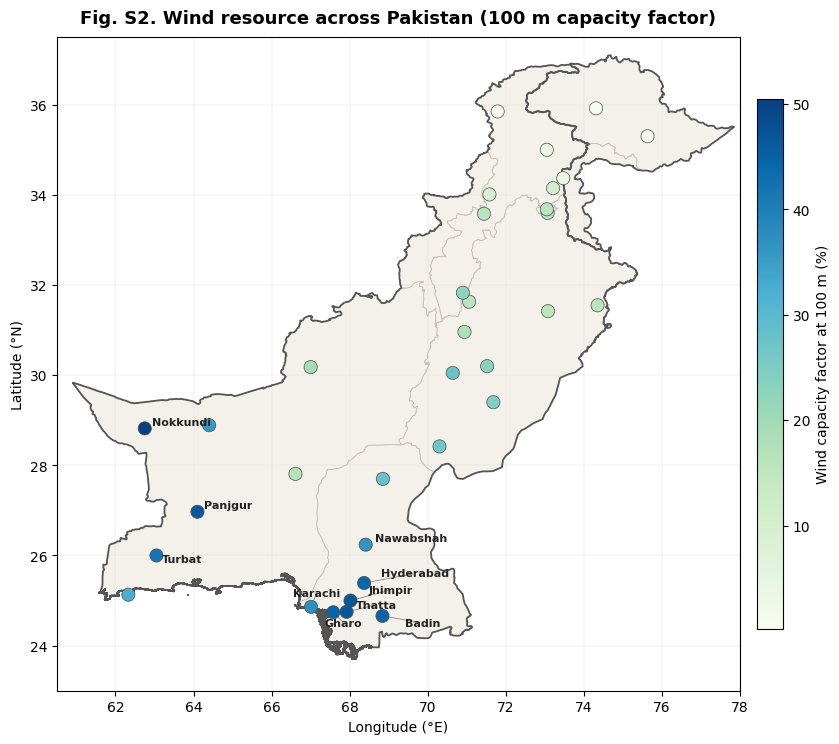

In [5]:
# =============================================================================
#  PAKISTAN NATIONAL SOLAR & WIND POTENTIAL SURVEY  (Google Colab)
#  Queries NASA POWER climatology for ~34 cities across all provinces, applies
#  the STCASS solar/wind conversion, and renders two clean 300-dpi maps plus a
#  ranked table. Labels are auto-spaced (no map/text overlap).
#
#  SCOPE NOTE: this is a CLIMATOLOGY (annual-mean) resource approximation for a
#  national-context supplementary figure. It is distinct from the rigorous
#  HOURLY Eq.(1)-(3) computation at your three primary nodes (that stays the
#  main result). Both use identical physical constants.
# =============================================================================


# =========================== CELL 1 — INSTALL ================================
!pip -q install geopandas adjustText requests matplotlib-scalebar 2>/dev/null
print("Ready.")


# =========================== CELL 2 — CITIES + PHYSICS =====================
import numpy as np, pandas as pd

# STCASS constants (identical to your notebook)
G_STC, T_STC, ALPHA_P = 1000.0, 25.0, -0.004
ALPHA_S               = 0.143
VIN, VR, VOUT         = 3.0, 11.0, 25.0
HUB_H, MEAS_H         = 100.0, 50.0

# Candidate cities across every province/region (name, province, lon, lat)
CITIES = [
    # ---- Sindh ----
    ("Karachi","Sindh",67.01,24.86), ("Hyderabad","Sindh",68.37,25.39),
    ("Jhimpir","Sindh",68.02,25.00), ("Gharo","Sindh",67.58,24.74),
    ("Thatta","Sindh",67.92,24.75), ("Nawabshah","Sindh",68.41,26.24),
    ("Sukkur","Sindh",68.85,27.70), ("Badin","Sindh",68.84,24.66),
    # ---- Punjab ----
    ("Lahore","Punjab",74.35,31.55), ("Multan","Punjab",71.52,30.20),
    ("Bahawalpur","Punjab",71.68,29.40), ("Dera Ghazi Khan","Punjab",70.64,30.05),
    ("Rahim Yar Khan","Punjab",70.30,28.42), ("Faisalabad","Punjab",73.08,31.42),
    ("Bhakkar","Punjab",71.06,31.63), ("Layyah","Punjab",70.94,30.96),
    ("Rawalpindi","Punjab",73.07,33.60),
    # ---- Khyber Pakhtunkhwa ----
    ("Peshawar","KP",71.58,34.01), ("Kohat","KP",71.44,33.58),
    ("Dera Ismail Khan","KP",70.90,31.83), ("Chitral","KP",71.79,35.85),
    ("Abbottabad","KP",73.21,34.15), ("Dassu (Kohistan)","KP",73.05,35.00),
    # ---- Balochistan ----
    ("Quetta","Balochistan",67.00,30.18), ("Gwadar","Balochistan",62.33,25.13),
    ("Nokkundi","Balochistan",62.75,28.82), ("Dalbandin","Balochistan",64.40,28.89),
    ("Khuzdar","Balochistan",66.61,27.81), ("Turbat","Balochistan",63.05,26.00),
    ("Panjgur","Balochistan",64.10,26.97),
    # ---- GB / AJK / ICT ----
    ("Gilgit","GB",74.31,35.92), ("Skardu","GB",75.63,35.30),
    ("Muzaffarabad","AJK",73.47,34.37), ("Islamabad","ICT",73.05,33.68),
]

def pv_cf_annual(ghi_ann_kwh, tmean):
    """Annual-mean PV CF from climatology (annual GHI kWh/m2/yr, mean T)."""
    gbar = ghi_ann_kwh * 1000.0 / 8760.0            # mean irradiance, W/m2
    return float(np.clip(gbar / G_STC * (1 + ALPHA_P * (tmean - T_STC)), 0, 1))

def wind_cf_rayleigh(vbar50):
    """Wind CF from mean 50 m speed via Rayleigh distribution (IEC standard)."""
    vbar100 = vbar50 * (HUB_H / MEAS_H) ** ALPHA_S
    v = np.linspace(0, 40, 4000)
    sigma = vbar100 * np.sqrt(2 / np.pi)            # Rayleigh: mean = sigma*sqrt(pi/2)
    pdf = (v / sigma**2) * np.exp(-v**2 / (2 * sigma**2))
    pc = np.where(v < VIN, 0.0,
         np.where(v < VR, (v - VIN) / (VR - VIN),
         np.where(v < VOUT, 1.0, 0.0)))
    cf = np.trapz(pc * pdf, v) / np.trapz(pdf, v)
    return float(cf), float(vbar100)


# =========================== CELL 3 — QUERY NASA POWER ====================
import requests, time, os

CACHE = "pakistan_city_potential.csv"
POWER = ("https://power.larc.nasa.gov/api/temporal/climatology/point"
         "?parameters=ALLSKY_SFC_SW_DWN,T2M,WS50M&community=RE"
         "&longitude={lon}&latitude={lat}&format=JSON")

def fetch(lon, lat, retries=3):
    for k in range(retries):
        try:
            r = requests.get(POWER.format(lon=lon, lat=lat), timeout=60)
            p = r.json()["properties"]["parameter"]
            ghi_day = p["ALLSKY_SFC_SW_DWN"]["ANN"]   # kWh/m2/day
            tmean   = p["T2M"]["ANN"]                 # deg C
            ws50    = p["WS50M"]["ANN"]               # m/s
            return ghi_day, tmean, ws50
        except Exception as e:
            time.sleep(3 * (k + 1))
    raise RuntimeError(f"NASA POWER failed at {lon},{lat}")

if os.path.exists(CACHE):                              # avoid re-querying on re-run
    df = pd.read_csv(CACHE)
    print(f"Loaded cached results ({len(df)} cities).")
else:
    rows = []
    for i, (name, prov, lon, lat) in enumerate(CITIES, 1):
        ghi_day, tmean, ws50 = fetch(lon, lat)
        ghi_ann = ghi_day * 365.25                     # kWh/m2/yr
        pvcf = pv_cf_annual(ghi_ann, tmean)
        wcf, v100 = wind_cf_rayleigh(ws50)
        rows.append(dict(city=name, prov=prov, lon=lon, lat=lat,
                         GHI_kWh_m2_yr=round(ghi_ann),
                         PV_CF_pct=round(pvcf * 100, 2),
                         v100_m_s=round(v100, 2),
                         Wind_CF_pct=round(wcf * 100, 2),
                         Tmean_C=round(tmean, 1)))
        print(f"  {i:2d}/{len(CITIES)}  {name:<18} GHI={ghi_ann:4.0f}  "
              f"PVcf={pvcf*100:4.1f}%  v100={v100:4.2f}  Wcf={wcf*100:4.1f}%")
        time.sleep(0.6)                                # be gentle to the API
    df = pd.DataFrame(rows)
    df.to_csv(CACHE, index=False)
    print(f"\nSaved {CACHE}")

# ranked views
solar_rank = df.sort_values("GHI_kWh_m2_yr", ascending=False).reset_index(drop=True)
wind_rank  = df.sort_values("Wind_CF_pct",  ascending=False).reset_index(drop=True)
print("\nTOP 8 SOLAR:\n", solar_rank[["city","prov","GHI_kWh_m2_yr","PV_CF_pct"]].head(8).to_string(index=False))
print("\nTOP 8 WIND:\n",  wind_rank[["city","prov","v100_m_s","Wind_CF_pct"]].head(8).to_string(index=False))
df.to_csv("STCASS_national_city_potential.csv", index=False)


# =========================== CELL 4 — SHARED MAP SETUP ====================
import warnings; warnings.filterwarnings("ignore")
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.linewidth": 0.8, "savefig.dpi": 300})

GADM = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_PAK.gpkg"
country   = gpd.read_file(GADM, layer="ADM_ADM_0")
provinces = gpd.read_file(GADM, layer="ADM_ADM_1")
gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df.lon, df.lat)],
                       crs="EPSG:4326")
ASPECT = 1 / np.cos(np.radians(30))     # latitude correction for EPSG:4326

def base_map(ax, title):
    provinces.plot(ax=ax, color="#f4f1ea", edgecolor="#c3bdb1", linewidth=0.6, zorder=1)
    country.boundary.plot(ax=ax, color="#555", linewidth=1.3, zorder=2)
    ax.set_aspect(ASPECT)
    ax.set_xlim(60.5, 78); ax.set_ylim(23, 37.5)
    ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
    ax.set_title(title, fontsize=13, weight="bold", pad=10)
    ax.grid(True, linewidth=0.3, color="#dddddd", zorder=0)

def label_top(ax, sub, value_col, unit):
    texts = []
    for _, r in sub.iterrows():
        texts.append(ax.text(r.lon, r.lat, r.city, fontsize=8, zorder=6,
                             weight="bold", color="#222"))
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle="-", color="#888", lw=0.6),
                expand_points=(1.4, 1.6), only_move={"points": "xy", "text": "xy"})


# =========================== CELL 5 — SOLAR MAP (300 dpi) =================
fig, ax = plt.subplots(figsize=(9, 8))
base_map(ax, "Fig. S1. Solar resource across Pakistan (annual GHI)")
sc = ax.scatter(gdf.lon, gdf.lat, c=gdf.GHI_kWh_m2_yr, s=90, cmap="YlOrRd",
                edgecolor="#4d4d4d", linewidth=0.5, vmin=df.GHI_kWh_m2_yr.min(),
                vmax=df.GHI_kWh_m2_yr.max(), zorder=5)
cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("Annual GHI (kWh m⁻² yr⁻¹)")
label_top(ax, solar_rank.head(10), "GHI_kWh_m2_yr", "kWh")   # label 10 best only
plt.tight_layout()
fig.savefig("Fig_S1_solar_potential.png", dpi=300, bbox_inches="tight")
fig.savefig("Fig_S1_solar_potential.pdf", bbox_inches="tight")
print("Saved solar map."); plt.show()


# =========================== CELL 6 — WIND MAP (300 dpi) ==================
fig, ax = plt.subplots(figsize=(9, 8))
base_map(ax, "Fig. S2. Wind resource across Pakistan (100 m capacity factor)")
sc = ax.scatter(gdf.lon, gdf.lat, c=gdf.Wind_CF_pct, s=90, cmap="GnBu",
                edgecolor="#4d4d4d", linewidth=0.5, vmin=df.Wind_CF_pct.min(),
                vmax=df.Wind_CF_pct.max(), zorder=5)
cb = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("Wind capacity factor at 100 m (%)")
label_top(ax, wind_rank.head(10), "Wind_CF_pct", "%")
plt.tight_layout()
fig.savefig("Fig_S2_wind_potential.png", dpi=300, bbox_inches="tight")
fig.savefig("Fig_S2_wind_potential.pdf", bbox_inches="tight")
print("Saved wind map."); plt.show()

# Download:
# from google.colab import files
# for f in ["Fig_S1_solar_potential.pdf","Fig_S2_wind_potential.pdf",
#           "STCASS_national_city_potential.csv"]:
#     files.download(f)

Saved solar map.


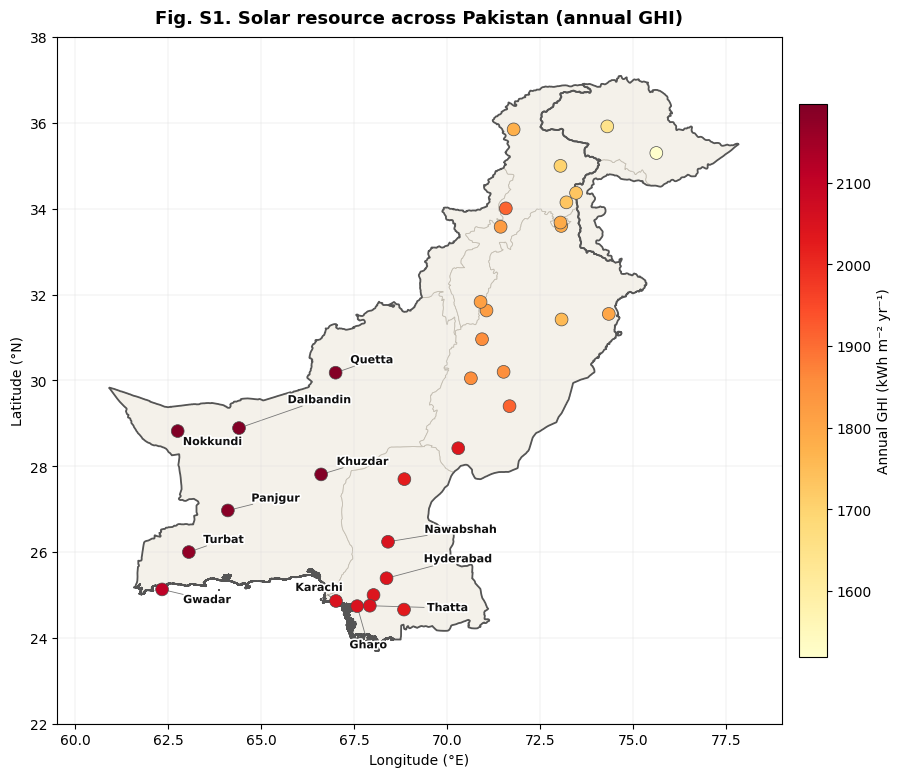

Saved wind map.


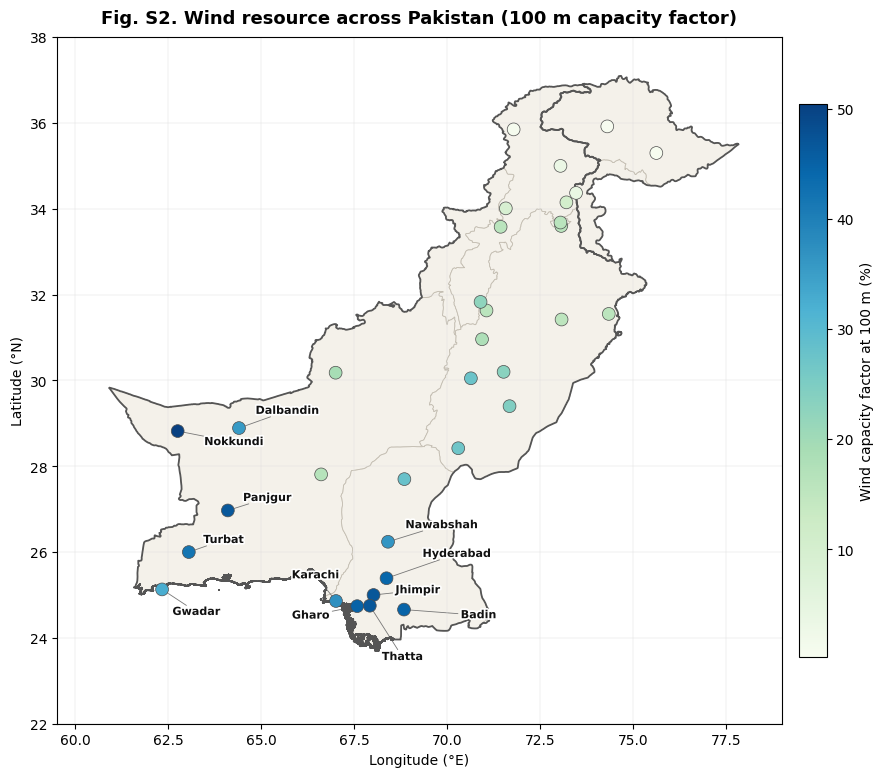

Saved Fig_S1_solar_potential.png/.pdf


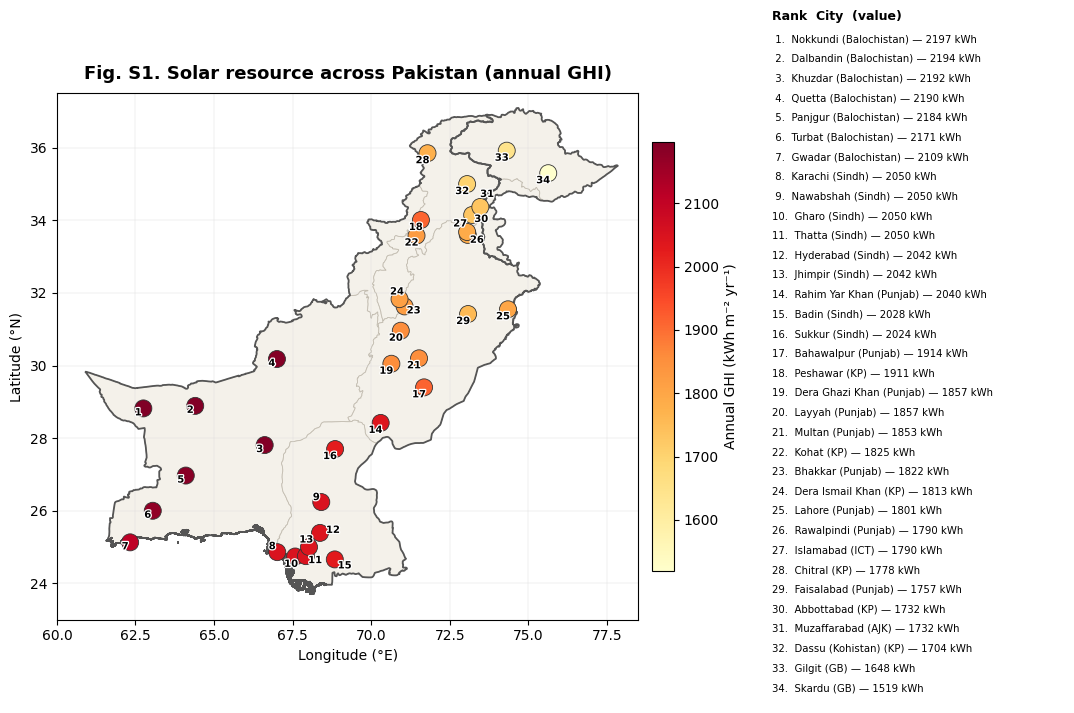

Saved Fig_S2_wind_potential.png/.pdf


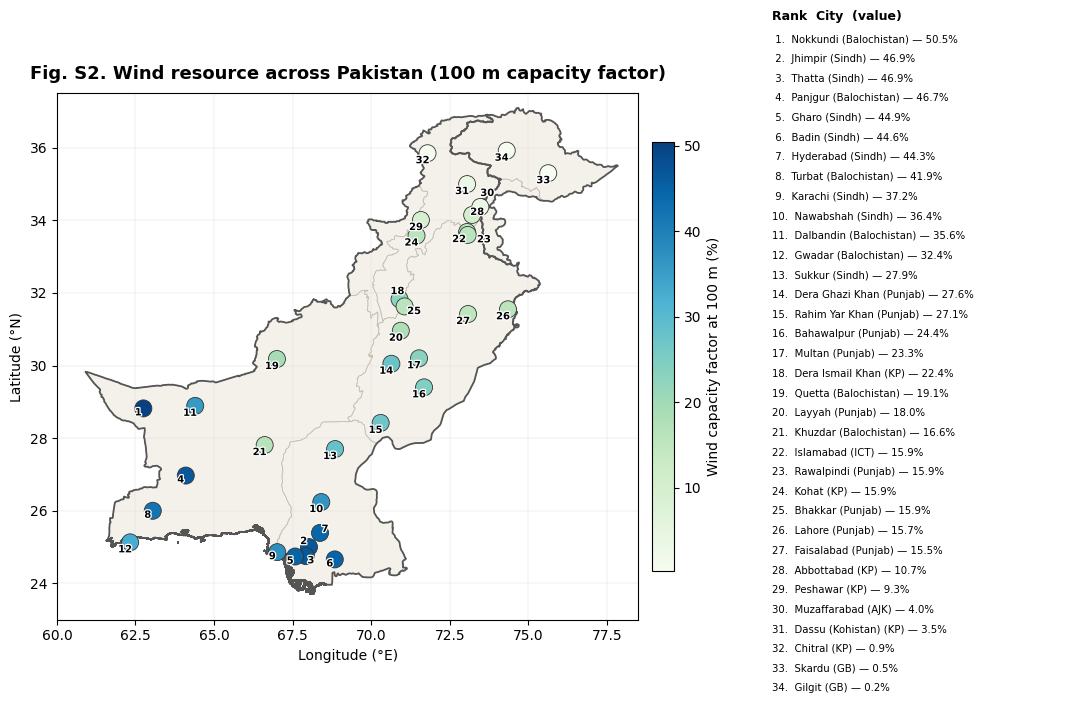

In [7]:
# =============================================================================
#  DEFINITIVE FIX — numbered markers + ranked side-legend
#  Replace CELL 4 + 5 + 6 of the national-survey script with this single cell.
#  Why this works: long city names in the dense southern cluster can never be
#  placed without adjustText dropping/clipping some. Here each dot carries a
#  small RANK NUMBER, and a complete ranked legend beside the map maps every
#  number to its city + value. No name can be missing — the legend IS the list.
#  Requires `df`, `solar_rank`, `wind_rank` from CELL 3.
# =============================================================================

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
try:
    from adjustText import adjust_text
    _HAVE_ADJUST = True
except Exception:
    _HAVE_ADJUST = False

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.linewidth": 0.8, "savefig.dpi": 300})

# --- boundaries (reuse if already loaded) ----------------------------------
GADM = "https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_PAK.gpkg"
try:
    provinces; country
except NameError:
    country   = gpd.read_file(GADM, layer="ADM_ADM_0")
    provinces = gpd.read_file(GADM, layer="ADM_ADM_1")

ASPECT = 1 / np.cos(np.radians(30))


def make_map(rank_df, value_col, cmap, cbar_label, val_fmt, title, outfile):
    """Numbered dots on the map + full ranked legend on the right panel."""
    sub = rank_df.reset_index(drop=True).copy()
    sub["rank"] = sub.index + 1

    fig = plt.figure(figsize=(13, 9))
    gs = GridSpec(1, 2, width_ratios=[3.0, 1.25], wspace=0.03)
    ax  = fig.add_subplot(gs[0])
    axL = fig.add_subplot(gs[1]); axL.axis("off")

    # --- base map ---
    provinces.plot(ax=ax, color="#f4f1ea", edgecolor="#c3bdb1",
                   linewidth=0.6, zorder=1)
    country.boundary.plot(ax=ax, color="#555", linewidth=1.3, zorder=2)
    ax.set_aspect(ASPECT)
    ax.set_xlim(60, 78.5); ax.set_ylim(23, 37.5)
    ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
    ax.set_title(title, fontsize=13, weight="bold", pad=10)
    ax.grid(True, linewidth=0.3, color="#dddddd", zorder=0)

    # --- coloured dots ---
    sc = ax.scatter(sub.lon, sub.lat, c=sub[value_col], s=150, cmap=cmap,
                    edgecolor="#333", linewidth=0.6,
                    vmin=sub[value_col].min(), vmax=sub[value_col].max(), zorder=5)
    cb = fig.colorbar(sc, ax=ax, shrink=0.62, pad=0.02)
    cb.set_label(cbar_label)

    # --- rank numbers on dots (tiny → always placeable) ---
    texts = []
    for _, r in sub.iterrows():
        t = ax.text(r.lon, r.lat, str(int(r["rank"])), fontsize=7.2,
                    weight="bold", ha="center", va="center",
                    color="black", zorder=9, clip_on=False)
        t.set_path_effects([pe.withStroke(linewidth=1.8, foreground="white")])
        texts.append(t)
    if _HAVE_ADJUST:
        try:
            adjust_text(texts, ax=ax, expand=(1.3, 1.5),
                        force_text=(0.4, 0.6),
                        arrowprops=dict(arrowstyle="-", color="#888", lw=0.5))
        except TypeError:
            adjust_text(texts, ax=ax,
                        arrowprops=dict(arrowstyle="-", color="#888", lw=0.5))

    # --- ranked legend panel (complete list; nothing can be missing) ---
    axL.set_xlim(0, 1); axL.set_ylim(0, 1)
    axL.text(0.0, 1.0, "Rank  City  (value)", fontsize=9, weight="bold",
             va="top")
    n = len(sub); y0, y1 = 0.965, 0.0
    step = (y0 - y1) / n
    for _, r in sub.iterrows():
        axL.text(0.0, y0 - (r["rank"] - 1) * step,
                 f"{int(r['rank']):>2}.  {r.city} ({r.prov}) — "
                 f"{val_fmt.format(r[value_col])}",
                 fontsize=7.3, va="top")

    fig.savefig(outfile + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(outfile + ".pdf", bbox_inches="tight")
    print("Saved", outfile + ".png/.pdf")
    plt.show()


# --- SOLAR map (ranked by annual GHI) --------------------------------------
make_map(solar_rank, "GHI_kWh_m2_yr", "YlOrRd",
         "Annual GHI (kWh m⁻² yr⁻¹)", "{:.0f} kWh",
         "Fig. S1. Solar resource across Pakistan (annual GHI)",
         "Fig_S1_solar_potential")

# --- WIND map (ranked by 100 m capacity factor) ----------------------------
make_map(wind_rank, "Wind_CF_pct", "GnBu",
         "Wind capacity factor at 100 m (%)", "{:.1f}%",
         "Fig. S2. Wind resource across Pakistan (100 m capacity factor)",
         "Fig_S2_wind_potential")

# from google.colab import files
# for f in ["Fig_S1_solar_potential.pdf","Fig_S2_wind_potential.pdf"]:
#     files.download(f)